In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Categorical features
sex,smoker,region

In [7]:
# Data analysis

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


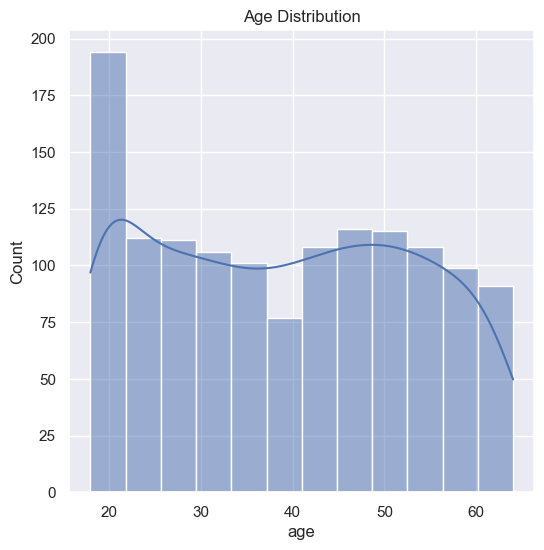

In [8]:
# Distribution of age value

sns.set()
plt.figure(figsize=(6,6))
sns.histplot(df['age'],kde = True)
plt.title('Age Distribution')
plt.show()

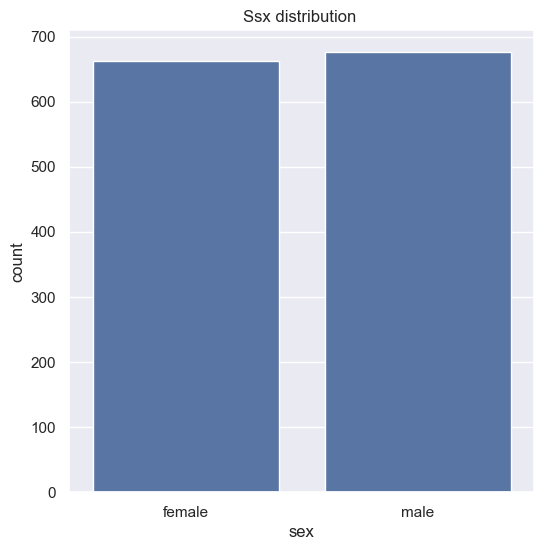

In [9]:
# Gender column

plt.figure(figsize =(6,6))
sns.countplot(x ='sex',data = df)
plt.title('Ssx distribution ')
plt.show()

In [10]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

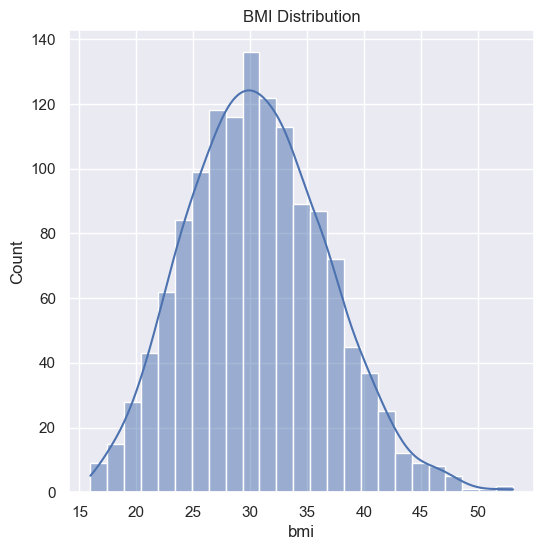

In [11]:
plt.figure(figsize=(6,6))
sns.histplot(df['bmi'],kde = True)
plt.title('BMI Distribution')
plt.show()

Normal bmi -> 18.5 - 24.9


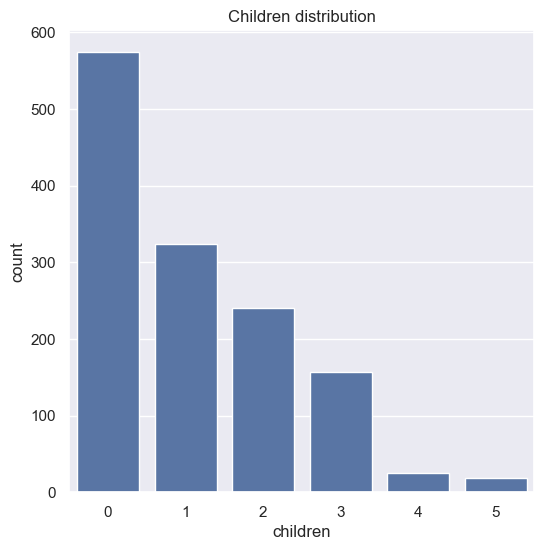

In [12]:
plt.figure(figsize =(6,6))

sns.countplot(x ='children',data= df)
plt.title("Children distribution")
plt.show()

In [13]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

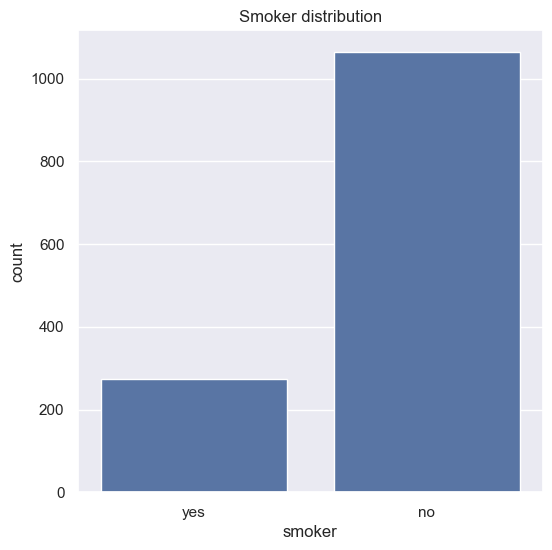

In [14]:
# smoker Column

plt.figure(figsize =(6,6))

sns.countplot(x ='smoker',data= df)
plt.title("Smoker distribution")
plt.show()

In [15]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

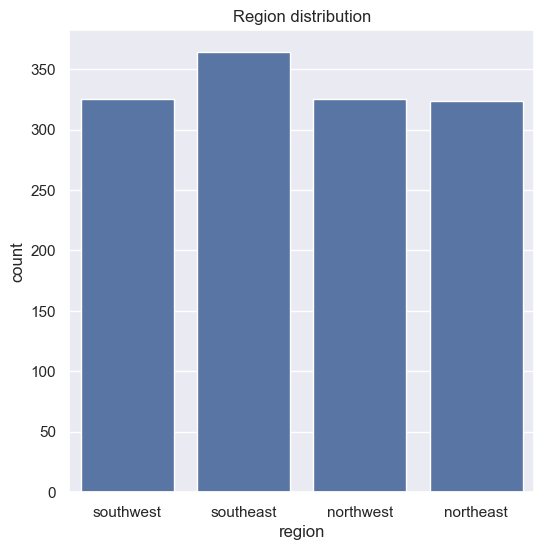

In [16]:
# Region column

plt.figure(figsize =(6,6))

sns.countplot(x ='region',data= df)
plt.title("Region distribution")
plt.show()

In [17]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

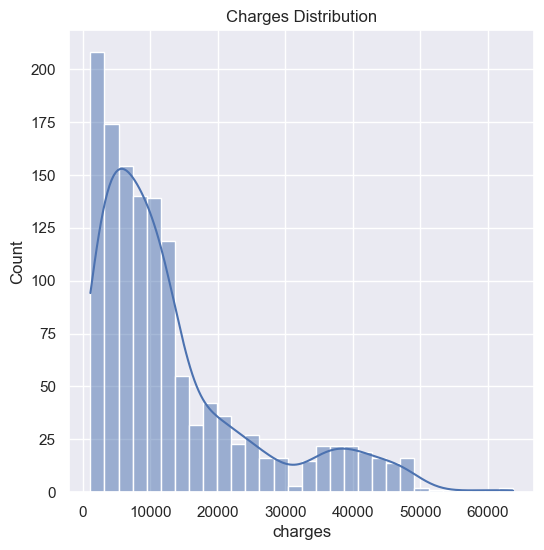

In [18]:
plt.figure(figsize=(6,6))
sns.histplot(df['charges'],kde = True)
plt.title('Charges Distribution')
plt.show()

# Data Preprocessing

In [20]:
# Encoding catagorical features

df.replace({'sex':{'male':0,'female':1}},inplace = True)

df.replace({'smoker':{'yes':0,'no':1}},inplace = True)

df.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace = True)

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


# Spliting the features 

In [22]:
X = df.drop('charges',axis = 1)
y = df['charges']

In [23]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,0,1
1,18,0,33.770,1,1,0
2,28,0,33.000,3,1,0
3,33,0,22.705,0,1,3
4,32,0,28.880,0,1,3


In [24]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [27]:
# Train test and split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 2
)

In [28]:
# Model training

model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [34]:
# Predicting on the training data
from sklearn.metrics import r2_score,accuracy_score,precision_score
train_pred = model.predict(X_train)


print("R2 score: ",r2_score(y_train,train_pred))


R2 score:  0.751505643411174


In [36]:
# Predicting on testing data

y_pred = model.predict(X_test)

print("R2 score: ",r2_score(y_test,y_pred))
print("R2 score: ",r2_score(y_pred,y_test))

R2 score:  0.7447273869684077


# Building a predictive system

In [40]:
input_data = (31,1,25.74,0,1,0)

# changing it into numpy array

input_np = np.asarray(input_data)

# Reshape the array
input_data_reshape =input_np.reshape(1,-1)

prediction = model.predict(input_data_reshape)
print(prediction)
print(prediction[0])

[3760.0805765]
3760.0805764960496


C:\Users\V.Bhargav\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
